In [1]:
import cv2
import pytesseract
import matplotlib.pyplot as plt
import numpy as np
import re
import glob
import random
from skimage.color import deltaE_ciede2000, rgb2lab

In [2]:
#print version of pytesseract 
print("verions:", pytesseract.get_tesseract_version())

verions: 4.1.1


# Several images:

In [3]:
def process_image (image):
    # Preprocess the image (convert to grayscale and apply thresholding)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)

    # Use Tesseract to do OCR on the image
    custom_config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789.'


    #custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(thresh, config=custom_config)
    print(text)
    return thresh, text


def process_region(region):
    # Preprocess the image (convert to grayscale and apply thresholding)
    thresh, text = process_image(region)
    numbers = re.findall(r"\d+\.?\d*", text)
    # add decimal point if there isn't
    for i in range(len(numbers)):
        if len(numbers[i]) == 3:
            numbers[i] = numbers[i][:2] + "." + numbers[i][2]
    return numbers

In [4]:
def all_images (path, plot=True):
    # Iterate through each image in the folder
    print(f"Processing: {path}")

    image = cv2.imread(path)
    if image is None:
        print(f"Error loading image: {path}")
        return
      
    if image.shape[1] > image.shape[0]: #landscape
        u = [15, 139, 70, 33]
        l = [15, 392, 70, 33]
    else:
        u = [15, 139, 70, 33]
        l = [15, 455, 70, 33]
    
    ux, uy, uw, uh = u  # Upper region
    lx, ly, lw, lh = l  # Lower region
    
    # image[y:y+h, x:x+w]
    square_region_upper = image[uy:uy+uh, ux:ux+uw]
    square_region_lower = image[ly:ly+lh, lx:lx+lw]
    
    if plot:
        plt.figure(figsize=(3, 1))  # Adjust size for better visualization
        
        plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
        plt.imshow(cv2.cvtColor(square_region_upper, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
        plt.imshow(cv2.cvtColor(square_region_lower, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    numbers = process_region(square_region_upper)
    numbers2 = process_region(square_region_lower)
    
    if plot:
        if len(numbers) > 0 and len(numbers2) > 0:
            print(f"   Max Value: {max(numbers)}           |       Min Value: {min(numbers2)}")
            return float(max(numbers)), float(min(numbers2))
        
        elif numbers == []:
            print(f"Min Value: {min(numbers2)}")
            print("No max value detected")
        elif numbers2 == []:
            print(f"Max Value: {max(numbers)}")
            print("No min value detected")

        print("-" * 100)  # Separator for readability
    else: 
        return float(max(numbers)), float(min(numbers2))


## Horizontal:

500
Processing: /home/martina/codi2/40/23.10.24/HM20241023144110.jpeg


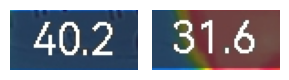

40.2

31.6

   Max Value: 40.2           |       Min Value: 31.6
Processing: /home/martina/codi2/40/23.10.24/HM20241023144212.jpeg


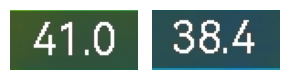

41.0

38.4

   Max Value: 41.0           |       Min Value: 38.4


In [4]:
import os
folder_path_horizontal = "/home/martina/codi2/40/23.10.24/"

# Get a list of all image files in the folder
image_paths_horizontal = sorted([f for f in glob.glob(os.path.join(folder_path_horizontal, "*")) if "VIS" not in f])

print(len(image_paths_horizontal)) 


for path in image_paths_horizontal[:2]:
    all_images(path)

## Vertical:


500
Processing: /home/martina/codi2/29/14.08.24-15.08.24/HM20240814213403.jpeg


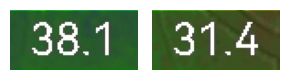

38.1

31.4

   Max Value: 38.1           |       Min Value: 31.4
Processing: /home/martina/codi2/29/14.08.24-15.08.24/HM20240814213507.jpeg


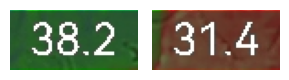

38.2

31.4

   Max Value: 38.2           |       Min Value: 31.4


In [5]:
folder_path_vertical = "/home/martina/codi2/29/14.08.24-15.08.24"

# Get a list of all image files in the folder
image_paths_vertical = sorted([f for f in glob.glob(os.path.join(folder_path_vertical, "*")) if "VIS" not in f])

print(len(image_paths_vertical)) 

# Get a list of all image files in the folder

for path in image_paths_vertical[:2]:
    all_images(path)


## Different formats and colors:

In [5]:
folder_path = "/home/martina/codi2/3year/synthesisII/diferent/*.jpeg"

# Get a list of all image files in the folder
image_paths = sorted(glob.glob(folder_path))

print(len(image_paths))

9


Processing: /home/martina/codi2/3year/synthesisII/diferent/a.jpeg


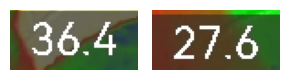

36.4

27.6

   Max Value: 36.4           |       Min Value: 27.6


In [12]:
for path in image_paths[-1:]:
    all_images(path)

# Grayscale:

We have noticed that the points with red color give lower temperatures than they should:

The color mapping from the thermal image might cause some issues when translating it to grayscale because the color-to-grayscale translation does not preserve the same temperature order


thermal image from hottest temperature to lowest are: white, red, orange, yellow, green, blue, purple/black. 

ordered colors in grayscale from darkest to whitest: black, blue, red, magenta, gray, green, cyan, yellow, white

In [ ]:

import numpy as np
from skimage.color import rgb2lab, deltaE_ciede2000
from joblib import Parallel, delayed
from PIL import Image

def color_to_temp_to_grayscale(image, newborn_id, max_temp, min_temp):
    # Define a fine-grained normalized temperature-to-color mapping TO PRESERVE THE ORDER OF THE TEMPERATURE SCALE. 
    # DICTIONARY GOES FROM 0 TO 1 SO THAT WE CAN USE THE MAX AND MIN TEMPERATURE VALUES TO NORMALIZE THE TEMPERATURES FOR EACH PICTURE ACCORDINGLY
    if newborn_id == "29" or newborn_id == "30" or newborn_id == "31" : #landscape
        print("baby is 29, 30 or 31, using first scale")
        temperature_colors = { 
            # yellow is after white (should be the hottest, so 1.00) 
            # and we go from white, yellow, red, green, blue, purple (coldest) (0.00 in grayscale normalized)
            1.00: (255, 255, 255), # White (hottest)
            0.95: (255, 255, 0),   # Yellow
            0.90: (255, 100, 0),   # Deep Orange
            0.80: (255, 0, 0),     # Red
            0.70: (255, 100, 100), # Light Red
            0.60: (255, 200, 0),   # Dark Yellow/Orange
            0.50: (0, 255, 0),     # Green
            0.40: (0, 128, 255),   # Light Blue
            0.30: (0, 0, 255),     # Blue
            0.20: (0, 0, 200),     # Deep Blue
            0.10: (75, 0, 130),    # Purple/Black (coldest)
            0.00: (0, 0, 0)        # Black (coldest)
        }
        
    else:
        temperature_colors = {
            0.00: (75, 0, 130),    # Purple/Black (coldest)
            0.10: (0, 0, 200),     # Deep Blue
            0.20: (0, 0, 255),     # Blue
            0.30: (0, 128, 255),   # Light Blue
            0.40: (0, 255, 0),     # Green
            0.50: (173, 255, 47),  # Yellow-Green
            0.60: (255, 255, 0),   # Yellow
            0.70: (255, 200, 0),   # Dark Yellow/Orange
            0.75: (255, 165, 0),   # Orange
            0.80: (255, 100, 0),   # Deep Orange
            0.90: (255, 0, 0),     # Red
            0.95: (255, 100, 100), # Light Red
            1.00: (255, 255, 255)  # White (hottest)
        }

    # Convert dictionary to numpy arrays for processing
    normalized_temps = np.array(list(temperature_colors.keys())) # keys
    colors = np.array(list(temperature_colors.values()), dtype=np.uint8) # values
    
    # RGB to LAB because CIEDE2000 is more accurate in the LAB color space
    # LAB: difference between two colors in Lab space corresponds to how humans perceive the difference.
    # deltaE_ciede2000 computes the perceptual diff between two colors in LAB. this is so that we can find the closest color in the dictionary to each pixel
    colors_lab = rgb2lab(colors.reshape(1, -1, 3)).reshape(-1, 3)
    image_reshaped = image.reshape(-1, 3).astype(np.uint8)
    image_lab = rgb2lab(image_reshaped.reshape(1, -1, 3)).reshape(-1, 3)
    
    # split the image into chunks for parallel processing (function below)
    num_chunks = 8
    chunks = np.array_split(image_lab, num_chunks)
    
    def process_chunk(chunk):
        # Reshape chunk and colors_lab for broadcasting
        chunk_expanded = chunk[:, np.newaxis, :]  # Shape: (N_pixels_in_chunk, 1, 3)
        colors_lab_expanded = colors_lab[np.newaxis, :, :]  # Shape: (1, N_colors, 3)
        
        # compute difference for all pixels in the chunk and all colors in the dictionary
        distances = deltaE_ciede2000(chunk_expanded, colors_lab_expanded)  # Shape: (N_pixels_in_chunk, N_colors)
        
        closest_indices = np.argmin(distances, axis=1) # get closest color with the smallest deltaE (difference)
        return normalized_temps[closest_indices]
    
    # Process chunks in parallel
    results = Parallel(n_jobs=-1)(delayed(process_chunk)(chunk) for chunk in chunks)
    temperature_map = np.concatenate(results) # Concatenate the results
    
    # Reshape back to image dimensions
    temperature_map = temperature_map.reshape(image.shape[:2])
    
    # normalized temperature --> actual temperature range
    actual_temp_values = temperature_map * (max_temp - min_temp) + min_temp
    
    # tewmperature range --> grayscale (0-255) ensuring red (high temp) is white and blue (low temp) is black
    grayscale_image = np.clip((actual_temp_values - min_temp) / (max_temp - min_temp) * 255, 0, 255).astype(np.uint8)
    
    return grayscale_image

def normalize(value, min_val, max_val, new_min, new_max):
    return new_min + (value - min_val) * (new_max - new_min) / (max_val - min_val)

def check_correlation(path):
        """image_normal = cv2.imread(path)
        image
        if image_normal is None:
            print(f"Error loading image: {path}")
            return
        
        image = cv2.cvtColor(image_normal, cv2.COLOR_BGR2RGB)
        """
        image_normal = Image.open(path)
        #convert to BGR
        image_normal = image_normal.convert("RGB")
        # convert to numpy array and BGR
        image = np.array(image_normal)
        
        max_temp, min_temp = all_images(path, plot=False) # get the max and min values from the image
        
        print(f"Max Temp: {max_temp} - Min Temp: {min_temp}")
        grayscale_image = color_to_temp_to_grayscale(image, "29", max_temp, min_temp) # RGB --> grayscale (with temperature mapping)

        print(grayscale_image.shape[:2])
        # select 5 random points in the image
        #points = [(random.randint(0, grayscale_image.shape[1] - 1), random.randint(0, grayscale_image.shape[0] - 1)) for _ in range(5)]
        points = [(573, 268), (513, 226), (486, 165), (511, 117), (511, 104), (388, 318), (286, 130), (223, 153)]
        
        print("Selected points:", points)
        
        #get grayscale values at the selected points
        pixel_values = [grayscale_image[y, x] for x, y in points]
        print("Pixel values at selected points:", pixel_values)
        
        
        # get temperatures by normalizing the value from grayscale to the temperature range
        temperatures = [normalize(value, 0, 255, min_temp, max_temp) for value in pixel_values]

        sorted_points = sorted(zip(points, pixel_values, temperatures), key=lambda p: (p[0][1], p[0][0])) # SORT FOR EASY READING OF WHICH POINT IS WHICH
        
        # Print
        print("coordinates - grayscale value - temperatures:")
        for (x, y), pixel, temp in sorted_points:
            print(f"({x}, {y}) - Grayscale value: {pixel}, Temperature: {temp:.1f}")
        
        # Plot the thermal and grayscale images marking the selected points
        plt.figure(figsize=(10, 5))  # Adjust size for better visualization
        plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
        plt.imshow(image_normal)
        for x, y in points:
            plt.plot(x, y, "wo")  # Mark the selected points with red circles          
        plt.axis("off")
        
        plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
        plt.imshow(grayscale_image, cmap="gray")
        for x, y in points:
            plt.plot(x, y, "ro")  # Mark the selected points with red circles
        plt.axis("off")
        
        plt.tight_layout()
        plt.show()
    
        print("-" * 100)  # Separator for readability

ALL IMAGES IN THE "DIFFERENT" FOLDER

In [131]:
folder_path = "/home/martina/codi2/3year/synthesisII/diferent/*.jpeg"

# Get a list of all image files in the folder
image_paths = sorted(glob.glob(folder_path))

print(len(image_paths))

10


Processing: /home/martina/codi2/3year/synthesisII/diferent/please.jpeg
36.3

28.3

Max Temp: 36.3 - Min Temp: 28.3
baby is 29, 30 or 31, using first scale
(480, 640)
Selected points: [(573, 268), (513, 226), (486, 165), (511, 117), (511, 104), (388, 318), (286, 130), (223, 153)]
Pixel values at selected points: [203, 242, 255, 203, 127, 203, 229, 203]
coordinates - grayscale value - temperatures:
(511, 104) - Grayscale value: 127, Temperature: 32.3
(511, 117) - Grayscale value: 203, Temperature: 34.7
(286, 130) - Grayscale value: 229, Temperature: 35.5
(223, 153) - Grayscale value: 203, Temperature: 34.7
(486, 165) - Grayscale value: 255, Temperature: 36.3
(513, 226) - Grayscale value: 242, Temperature: 35.9
(573, 268) - Grayscale value: 203, Temperature: 34.7
(388, 318) - Grayscale value: 203, Temperature: 34.7


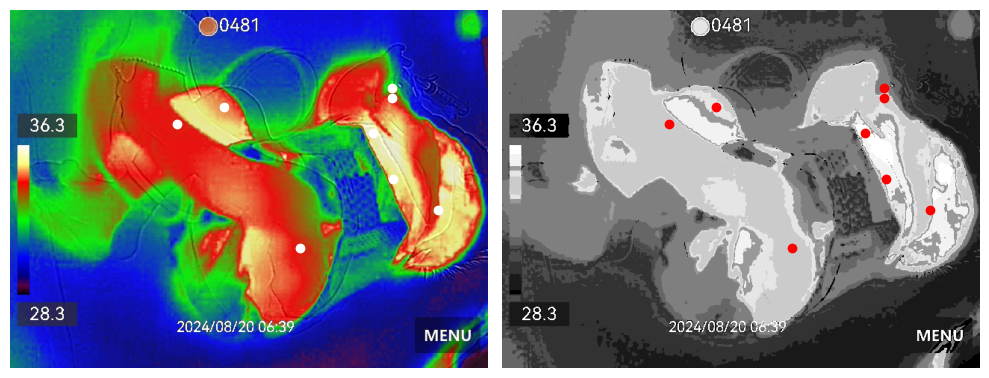

----------------------------------------------------------------------------------------------------


In [132]:
for path in image_paths[-1:]: 
    check_correlation(path)

7'57 min per 8 fotos

27 segons per 8 fotos - broadcasting (distances operation can be performed at once and without for loop) & parallel